<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1285 | Val: 362 | Test: 203


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 4, accumulation steps = 30 (effective batch size ≈ 120, tuned value = 121)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 30 micro-batches per optimizer step (effective batch size ≈ micro_batch x 30).
[ResNet-50] Epoch   1/100 | LR: 2.68e-05 | train loss 1.3779 acc 0.419 | val loss 1.3518 acc 0.450 *
[ResNet-50] Epoch   2/100 | LR: 2.68e-05 | train loss 1.3274 acc 0.448 | val loss 1.2350 acc 0.450 *
[ResNet-50] Epoch   3/100 | LR: 2.68e-05 | train loss 1.2507 acc 0.448 | val loss 1.2044 acc 0.517 *
[ResNet-50] Epoch   4/100 | LR: 2.68e-05 | train loss 1.2089 acc 0.488 | val loss 1.1317 acc 0.597 *
[ResNet-50] Epoch   5/100 | LR: 2.68e-05 | train loss 1.1823 acc 0.538 | val loss 1.1762 acc 0.564
[ResNet-50] Epoch   6/100 | LR: 2.68e-05 | train loss 1.1663 acc 0.561 | val loss 1.1068 acc 0.627 *
[ResNet-50] Epoch   7/100 | LR: 2.68e-05 | train loss 1.1446 acc 0.579 | val loss 1.0707 acc 0.597 *
[ResNet-50] Epoch   8/100 | LR: 2.68e-05 | train loss 1.1233 acc 0.570 | val loss 1.0167 acc 0.602 *
[ResNet-50] Epoch   9/100 | LR: 2.68e-05 | train loss 1.1076 acc 0.570 | v

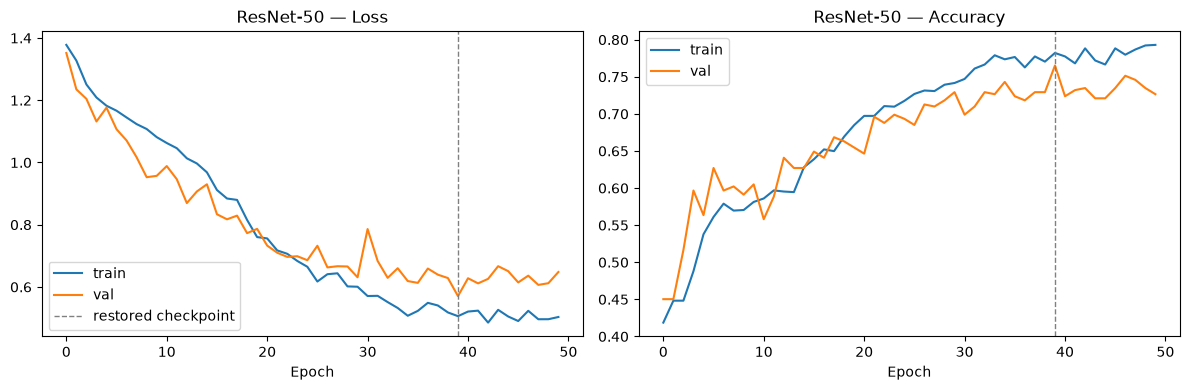

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.808


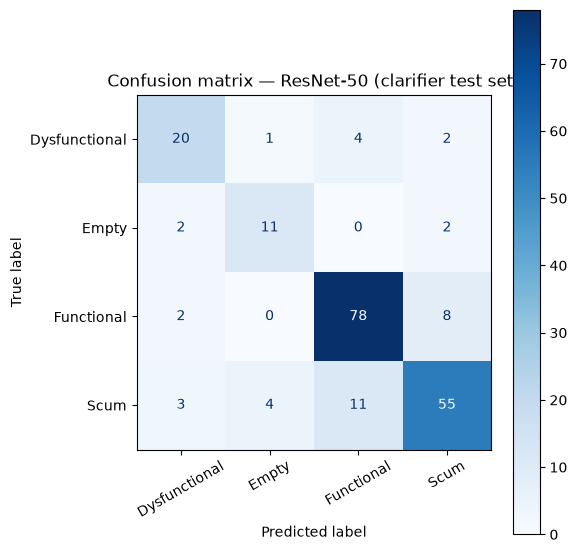

               precision    recall  f1-score   support

Dysfunctional      0.741     0.741     0.741        27
        Empty      0.688     0.733     0.710        15
   Functional      0.839     0.886     0.862        88
         Scum      0.821     0.753     0.786        73

     accuracy                          0.808       203
    macro avg      0.772     0.778     0.775       203
 weighted avg      0.808     0.808     0.807       203



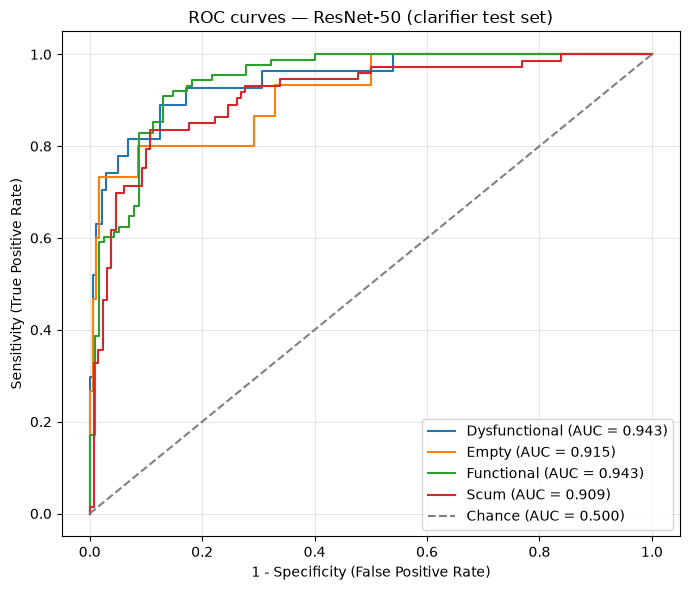

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.943
  Empty          : 0.915
  Functional     : 0.943
  Scum           : 0.909

Mean AUC: 0.928


(np.float64(0.8078817733990148),
 {'Dysfunctional': 0.9433922558922558,
  'Empty': 0.9148936170212767,
  'Functional': 0.9432806324110672,
  'Scum': 0.9090621707060064})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/results_resnet50.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
